In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random

Matplotlib is building the font cache; this may take a moment.


In [4]:
from nazi_symbols_classification.training.data_preparation import get_image_paths

In [6]:
image_files = get_image_paths("/Users/zhiwei.zhang/Projects/nazi-symbols-classification/notebooks/datasets/nazi-symbols-detection", 
                              ("train", "test", "valid"))

Total Images: 19511


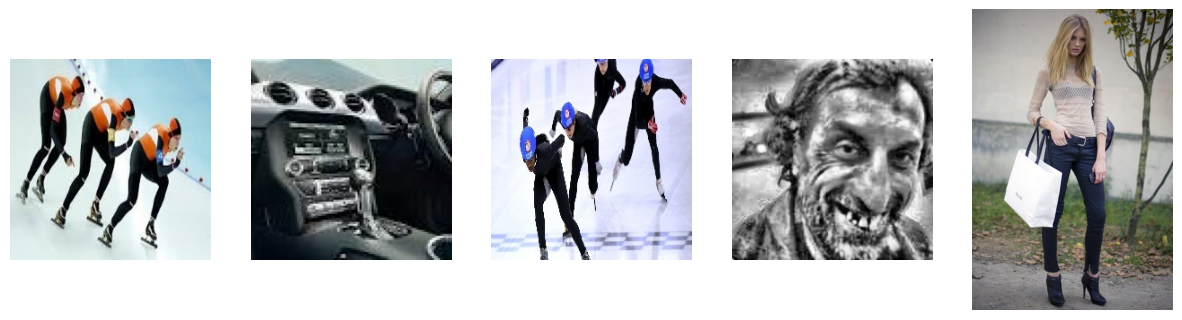

In [7]:
print(f"Total Images: {len(image_files)}")

# Display sample images
sample_images = random.sample(image_files, 5)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, img_file in zip(axes, sample_images):
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
plt.show()

In [11]:
os.path.basename(os.path.dirname(image_files[0]))

'nazi-symbol'

In [13]:
labels = [os.path.basename(os.path.dirname(image_file)) for image_file in image_files]

In [15]:
import pandas as pd

df = pd.DataFrame({"path": image_files, "label": labels})
df.head()

,path,label
0,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,nazi-symbol
1,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,nazi-symbol
2,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,nazi-symbol
3,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,nazi-symbol
4,/Users/zhiwei.zhang/Projects/nazi-symbols-clas...,nazi-symbol


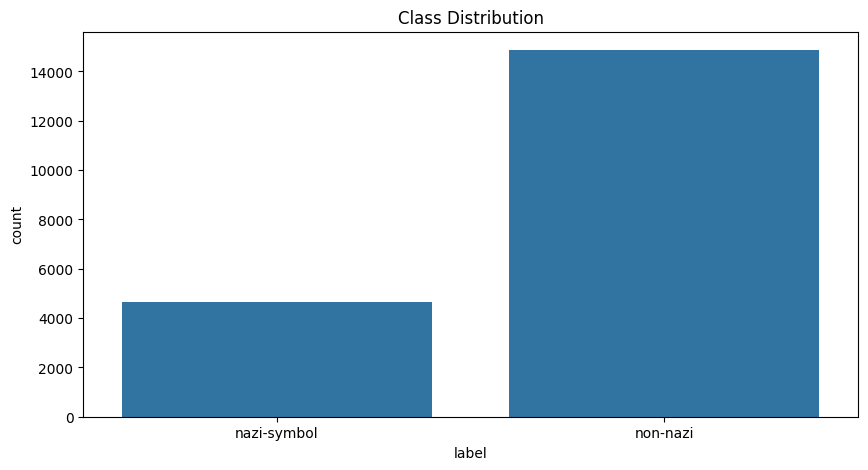

In [16]:
import seaborn as sns

# Plot class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()

In [17]:
import numpy as np

# Compute mean and std deviation across dataset
means, stds = [], []
for img_file in image_files:
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.mean(means, axis=0)
stds = np.mean(stds, axis=0)
print(f"Mean: {means}, Std Dev: {stds}")


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Mean: [0.49813328 0.49093336 0.47094314], Std Dev: [0.25831034 0.25602452 0.25764312]


In [18]:
def detect_blur(img_path, threshold=100):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var < threshold

blurred_images = [f for f in image_files if detect_blur(f)]
print(f"Blurred Images: {len(blurred_images)}")


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Blurred Images: 676


In [19]:
!pip install torchvision


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


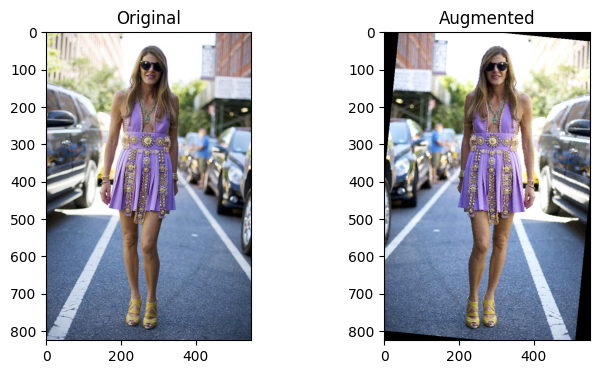

In [20]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

img = Image.open(random.choice(image_files))
augmented_img = transform(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(augmented_img)
plt.title("Augmented")
plt.show()


In [34]:
import torch
from open_clip import create_model_and_transforms
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = create_model_and_transforms(
    'ViT-B-32', pretrained='/Users/zhiwei.zhang/Projects/nazi-symbols-classification/data/open_clip_pytorch_model.bin',
    cache_dir='/Users/zhiwei.zhang/Projects/nazi-symbols-classification/data', device=device)

img = preprocess(Image.open(image_files[0])).unsqueeze(0).to(device)
features = model.encode_image(img)
print(f"Feature vector shape: {features.shape}")


Feature vector shape: torch.Size([1, 512])


In [40]:
features.cpu().detach().numpy()

array([[-2.09312081e-01, -6.98441565e-01, -6.34396374e-01,
         5.48638880e-01, -5.40429890e-01,  2.26625100e-01,
         2.84344554e-01,  2.08011836e-01, -6.42613888e-01,
         6.07738912e-01,  1.41239343e-02,  1.43755153e-01,
         1.41004831e-01, -6.26698017e-01,  9.11155641e-02,
        -6.30012989e-01,  7.70283103e-01,  4.34962273e-01,
         2.91348457e-01, -3.06380659e-01,  4.49949503e-01,
         3.46105367e-01,  2.28180006e-01,  3.18208635e-01,
        -1.95844620e-01,  1.93467990e-01,  1.35320708e-01,
         4.24892843e-01, -1.14113279e-01, -7.14846626e-02,
        -9.89659667e-01,  6.05180971e-02, -3.34351897e-01,
        -8.98662880e-02, -1.50362730e-01,  4.63103168e-02,
        -8.32645595e-02, -1.07999168e-01,  5.83086833e-02,
         3.47145610e-02, -1.49965540e-01,  7.32460618e-02,
         4.25884396e-01, -2.97119796e-01, -5.36359334e-03,
         1.87539801e-01, -1.03783600e-01,  3.60980928e-01,
        -4.03051198e-01, -3.66055518e-01,  1.80058897e-0

In [43]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=2).fit(features.cpu().detach().numpy())
print(f"Number of outliers: {sum(dbscan.labels_ == -1)}")

Number of outliers: 1
